# Lecture 7.4: Ptychography Simulation and Reconstruction

In this lecture, we will explore how to simulate a 4D-STEM dataset for ptychography using `abTEM` and how to reconstruct the phase of the sample using `py4DSTEM`.

## Learning Objectives
1. Understand the experimental parameters that govern ptychographic reconstructions (probe overlap, sampling, defocus).
2. Simulate a 4D-STEM ptychography dataset of a complex atomic model using `abTEM`.
3. Reconstruct the phase of the sample using the Single-Slice Ptychography (SSP) algorithm in `py4DSTEM`.

In [ ]:
# Uncomment and run this cell if you are on Google Colab
# !pip install abtem py4DSTEM > /dev/null 2>&1

In [ ]:
%matplotlib inline

import abtem
import py4DSTEM
import ase
import ase.build
import matplotlib.pyplot as plt
import numpy as np

## 1. Experimental Design Parameters

There are a number of experimental parameters to consider when simulating or acquiring 4D-STEM data for ptychography, notably:
- **Convergence angle & accelerating voltage**: Determines the probe size and resolution.
- **Defocus**: Spreads the probe to ensure sufficient overlap between adjacent scan positions.
- **Scan (real-space) step size**: Determines the sampling in real space and the degree of probe overlap.
- **Maximum scattering angle**: Sets the reconstruction pixel size in real space.
- **Number of detector pixels**: Determines the size of the array used to store the moving-window probe. This has to be large enough to fit the defocused probe without wrap-around artifacts.

The first three parameters determine the extent of **probe overlap**, which is critical for ptychography. The maximum scattering angle sets the reconstruction pixel size. The number of detector pixels determines the size of the array used to store the moving-window probe.

We can get a sense of these parameters using a dummy dataset preprocessing function below:

In [ ]:
def dummy_dataset_preprocess(
    energy,
    semiangle_cutoff,
    defocus,
    scan_step_size_ang,
    maximum_scattering_angle_mrad,
    num_detector_pixels,
    sx=15, sy=15, object_padding_px=None,
):
    """
    Creates a dummy DataCube and runs the py4DSTEM ptychography preprocessor 
    to visualize probe overlap and detector sampling.
    """
    if object_padding_px is None:
        object_padding_px = (num_detector_pixels//4, num_detector_pixels//4)

    dummy_data = np.ones((sx, sy, num_detector_pixels, num_detector_pixels))
    dc = py4DSTEM.DataCube(dummy_data)
    dc.calibration.set_R_pixel_size(scan_step_size_ang)
    dc.calibration.set_R_pixel_units('A')
    dc.calibration.set_Q_pixel_size(2 * maximum_scattering_angle_mrad / num_detector_pixels)
    dc.calibration.set_Q_pixel_units('mrad')

    ptycho = py4DSTEM.process.phase.SingleslicePtychographicReconstruction(
        datacube=dc,
        verbose=False,
        energy=energy,
        semiangle_cutoff=semiangle_cutoff,
        defocus=defocus,
        object_padding_px=object_padding_px,
    ).preprocess(
        force_com_rotation=0,
        force_com_transpose=False,
        plot_rotation=False,
        plot_center_of_mass=False,
    )
    print(f"Reconstruction pixel size: {ptycho.sampling[0]:.4f} Å")
    print(f"Reconstruction object size: {ptycho.object_cropped.shape} px")

    return ptycho

### Exploring Probe Overlap
Let's start playing around with this! The following dataset does **not** have sufficient probe overlap. Notice the gaps between the circles in the overlap plot.

In [ ]:
ptycho_not_enough_overlap = dummy_dataset_preprocess(
    energy = 80e3, # V
    semiangle_cutoff = 20, # mrad
    defocus = 100, # Å
    scan_step_size_ang = 2.5, # Å
    maximum_scattering_angle_mrad = 80,
    num_detector_pixels = 48,
)

This lack of overlap can be remedied in one of three ways:

**1. Decreasing the convergence semiangle** (which affects the transfer of information and lowers resolution):

In [ ]:
ptycho_enough_overlap_small_alpha = dummy_dataset_preprocess(
    energy = 80e3,
    semiangle_cutoff = 10, # Decreased from 20 to 10 mrad
    defocus = 100,
    scan_step_size_ang = 2.5,
    maximum_scattering_angle_mrad = 80,
    num_detector_pixels = 48,
)

**2. Decreasing the scan step-size** (which increases dose and acquisition time for the same field of view):

In [ ]:
ptycho_enough_overlap_small_fov = dummy_dataset_preprocess(
    energy = 80e3,
    semiangle_cutoff = 20,
    defocus = 100,
    scan_step_size_ang = 1.0, # Decreased from 2.5 to 1.0 Å
    maximum_scattering_angle_mrad = 80,
    num_detector_pixels = 48,
)

**3. Increasing the defocus** (spreading the probe out further):

In [ ]:
ptycho_enough_overlap_probe_artifacts = dummy_dataset_preprocess(
    energy = 80e3,
    semiangle_cutoff = 20,
    defocus = 300, # Increased from 100 to 300 Å
    scan_step_size_ang = 2.5,
    maximum_scattering_angle_mrad = 80,
    num_detector_pixels = 48,
)

Notice however how our probe no longer fits in a (48, 48) array — leading to wrap-around artifacts in the detector plane. This can be remedied by using **more detector pixels**.

In [ ]:
ptycho_enough_overlap = dummy_dataset_preprocess(
    energy = 80e3,
    semiangle_cutoff = 20,
    defocus = 300,
    scan_step_size_ang = 2.5,
    maximum_scattering_angle_mrad = 80,
    num_detector_pixels = 96, # Increased from 48 to 96
)

The above might appear as a moot point, considering most detectors have a fixed number of pixels anyway. However, in ptychographic reconstructions we often want to **bin** the 4D-STEM data to increase our signal-to-noise ratio, dynamic range, and computational efficiency.

Finally, let's see the effect of the **maximum scattering angle** on our setup:

In [ ]:
ptycho_enough_overlap_lower_resolution = dummy_dataset_preprocess(
    energy = 80e3,
    semiangle_cutoff = 20,
    defocus = 300,
    scan_step_size_ang = 2.5,
    maximum_scattering_angle_mrad = 40, # Decreased from 80 to 40 mrad
    num_detector_pixels = 48,
)

We can achieve the same setup as above by using only (48, 48) detector pixels and half the maximum scattering angle. However, notice that our **reconstruction pixel size is now twice as large** (lower resolution).

In general, you should only simulate/collect data up to scattering angles where you have sufficient counts. In detectors with a small dynamic range, this is often restricted to the bright field disk. In detectors with a large dynamic range, collecting to higher angles (so-called "dark" electrons) enables super-resolution.

## 2. 'Complex' Atomic Model Simulation

Let's use the atomic simulation environment (`ase`) and `abtem` to simulate a complicated non-periodic field of view for use in ptychography.

We start by specifying the SrTiO$_3$ (STO) unit cell, creating a [110] slab, rotating it, and adding some vacuum to create a nanoparticle-like structure.

In [ ]:
# 1. Define the STO unit cell
STO_unit_cell = ase.Atoms(
    'SrTiO3',
    positions=[
        [0.      , 0.      , 0.      ],
        [1.972565, 1.972565, 1.972565],
        [0.      , 1.972565, 1.972565],
        [1.972565, 0.      , 1.972565],
        [1.972565, 1.972565, 0.      ]],
    cell=[3.94513, 3.94513, 3.94513]
)

# 2. Create a [110] slab with 4 layers
STO_slab = ase.build.surface(STO_unit_cell, (1, 1, 0), 4, periodic=True)

# 3. Tile the slab, rotate it, and carve out a specific region
STO_atoms = STO_slab * (4, 4, 2)
STO_atoms.rotate(20, 'z')
STO_atoms.positions[:, 1] += 5

# Remove atoms outside our desired bounding box
del STO_atoms[STO_atoms.positions[:, 0] > 30]
del STO_atoms[STO_atoms.positions[:, 0] < 0]
del STO_atoms[STO_atoms.positions[:, 1] > 30]
del STO_atoms[STO_atoms.positions[:, 1] < 0]

# Set the cell size to be large enough to avoid periodic artifacts
STO_atoms.cell[0, 0] = 30
STO_atoms.cell[1, 1] = 30

abtem.show_atoms(STO_atoms, plane='xy');

Note how we made the cell quite large, even though we don't plan on simulating the entire field-of-view, to avoid any periodic artifacts from the multislice simulation.

We define a grid-scan covering a quarter of the field-of-view, i.e., 31x31 probe positions with a scan step-size of 0.5 Å.

In [ ]:
scan_step_size = 0.5

gridscan = abtem.GridScan(
    start=(7.5, 7.5),
    end=(22.5, 22.5),
    sampling=scan_step_size,
    endpoint=True
)

abtem.show_atoms(STO_atoms, scans=gridscan);

We will define the number of detector pixels and our target real-space sampling. This will allow us to set the detector sampling and extent.

In [ ]:
num_detector_pixels = 80
target_sampling = 0.15
energy = 200e3
semiangle_cutoff = 20
defocus = 100

reciprocal_sampling = 1 / target_sampling / num_detector_pixels
wavelength = py4DSTEM.process.utils.electron_wavelength_angstrom(energy)
maximum_scattering_angle_mrad = reciprocal_sampling * num_detector_pixels / 2 * wavelength * 1000
resample = maximum_scattering_angle_mrad * 2 / num_detector_pixels

pixelated_detector = abtem.PixelatedDetector(
    max_angle=maximum_scattering_angle_mrad * 0.99, 
    resample=(resample, resample)
)

Before we run the simulation, we use our dummy preprocessing tool to check that our simulation parameters look good:
- [x] Our real-space probe fits comfortably in the cropping box.
- [x] There's sufficient probe overlap.

In [ ]:
pre_simulation_parameter_check = dummy_dataset_preprocess(
    energy = energy,
    semiangle_cutoff = semiangle_cutoff,
    defocus = defocus,
    scan_step_size_ang = scan_step_size,
    maximum_scattering_angle_mrad = maximum_scattering_angle_mrad,
    num_detector_pixels = num_detector_pixels,
    sx=31, sy=31
)

We then proceed to simulate our diffraction intensities. 

*Note: This step may take a minute or two depending on your hardware. We use `device='cpu'` here for compatibility, but you can change it to `'gpu'` if you have a compatible GPU.*

In [ ]:
potential = abtem.Potential(
    STO_atoms,
    sampling=0.1,
    projection="infinite",
    parametrization="kirkland",
    device='cpu' # Change to 'gpu' if available
)

probe = abtem.Probe(
    energy=energy, 
    semiangle_cutoff=semiangle_cutoff, 
    defocus=defocus, 
    device='cpu' # Change to 'gpu' if available
)

measurement = probe.scan(gridscan, pixelated_detector, potential)

Finally, we add some finite electron dose (Poisson noise) to make the simulation more realistic, and compare the results against the infinite dose simulation:

In [ ]:
from abtem.noise import poisson_noise

noisy_measurement = poisson_noise(measurement, dose=1e5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4))
measurement.mean((0, 1)).show(ax=ax1, power=0.25, cmap='magma')
ax1.set_title("Infinite Dose (Mean CBED)")

noisy_measurement.mean((0, 1)).show(ax=ax2, power=0.25, cmap='magma')
ax2.set_title("Finite Dose (Mean CBED)")

fig.tight_layout();

## 3. py4DSTEM Ptychographic Reconstruction

Now that we have our simulated 4D-STEM dataset, we can reconstruct the phase of the sample using single-slice ptychography in `py4DSTEM`.

First, we convert the `abTEM` measurement into a `py4DSTEM.DataCube` and set the appropriate calibrations.

In [ ]:
dc = py4DSTEM.DataCube(data=noisy_measurement.array)

# Set real-space (scan) calibrations
dc.calibration.set_R_pixel_size(noisy_measurement.calibrations[0].sampling)
dc.calibration.set_R_pixel_units('A')

# Set reciprocal-space (detector) calibrations
dc.calibration.set_Q_pixel_size(noisy_measurement.calibrations[-1].sampling)
dc.calibration.set_Q_pixel_units('mrad')

print(dc.calibration)

Next, we set up the `SingleslicePtychographicReconstruction` object, preprocess the data, and run the reconstruction using Gradient Descent (`GD`).

In [ ]:
ptycho = py4DSTEM.process.phase.SingleslicePtychographicReconstruction(
    datacube=dc,
    verbose=False,
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    defocus=defocus,
    object_padding_px=(12, 12),
    device='cpu', # Change to 'gpu' if available
).preprocess(
    plot_center_of_mass=False,
    plot_rotation=False,
    plot_probe_overlaps=False,
    force_com_rotation=0,
    force_com_transpose=False,
).reconstruct(
    progress_bar=True,
    reset=True,
    store_iterations=True,
    reconstruction_method='GD',
    max_iter=64,
    normalization_min=1,
    step_size=0.5,
).visualize(
    cbar=True,
)

If the reconstruction hasn't fully converged, we can continue running it for more iterations without resetting the state:

In [ ]:
ptycho.reconstruct(
    progress_bar=True,
    reset=False, # Do not reset, continue from previous state
    store_iterations=True,
    reconstruction_method='GD',
    max_iter=12,
    normalization_min=1,
    step_size=0.5,
).visualize(
    cbar=True,
)

# abTEM + py4DSTEM ptychography tutorial


In [ ]:
# for colab
# python package installation
!pip install abtem py4DSTEM > /dev/null 2>&1

In [ ]:
%matplotlib inline

import abtem
import py4DSTEM
import ase
import matplotlib.pyplot as plt
import numpy as np

## Experimental Design Parameters

There are a number of experimental parameters to consider when simulating 4DSTEM data for ptychography, notably:
- Convergence angle \& accelerating voltage
- Defocus
- Scan (real-space) step size
- Maximum scattering angle
- \# of detector pixels

The first three determine the extent of probe overlap.  
The maximum scattering angle sets the reconstruction pixel-size.  
The \# of detector pixels determines the size of the array used to store the moving-window probe. This has to be large enough to fit the defocused probe w/o wrap-around artifacts.

We can get a sense of these parameters using a dummy dataset below:

In [ ]:
def dummy_dataset_preprocess(
    energy,
    semiangle_cutoff,
    defocus,
    scan_step_size_ang,
    maximum_scattering_angle_mrad,
    num_detector_pixels,
    sx=15,sy=15,object_padding_px=None,
):
    """
    """

    if object_padding_px is None:
        object_padding_px = (num_detector_pixels//4,num_detector_pixels//4)

    dummy_data = np.ones((sx,sy,num_detector_pixels,num_detector_pixels))
    dc = py4DSTEM.DataCube(dummy_data)
    dc.calibration.set_R_pixel_size(scan_step_size_ang)
    dc.calibration.set_R_pixel_units('A')
    dc.calibration.set_Q_pixel_size(2*maximum_scattering_angle_mrad/num_detector_pixels)
    dc.calibration.set_Q_pixel_units('mrad')

    ptycho = py4DSTEM.process.phase.SingleslicePtychographicReconstruction(
        datacube=dc,
        verbose=False,
        energy=energy,
        semiangle_cutoff=semiangle_cutoff,
        defocus=defocus,
        object_padding_px=object_padding_px,
    ).preprocess(
        force_com_rotation=0,
        force_com_transpose=False,
        plot_rotation=False,
        plot_center_of_mass = False,
    )
    print(f"Reconstruction pixel size: {ptycho.sampling[0]:.4} A")
    print(f"Reconstruction object size: {ptycho.object_cropped.shape} px")

    return ptycho

Let's start playing around with this!
The following dataset does not have sufficient probe overlap:

Reconstruction pixel size: 0.261 A
Reconstruction object size: (136, 136) px


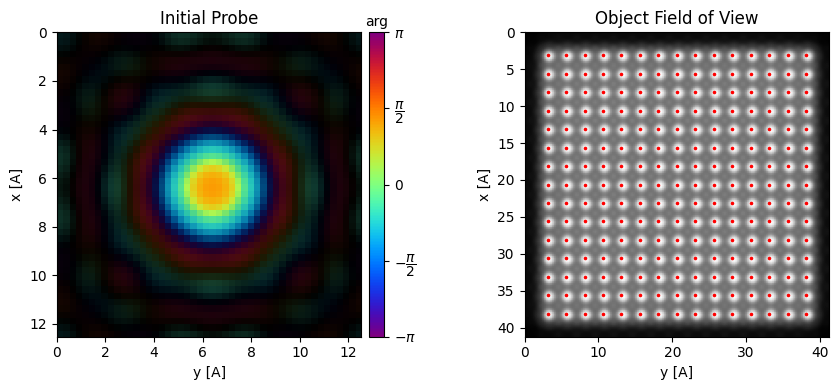

In [ ]:
%matplotlib inline

ptycho_not_enough_overlap = dummy_dataset_preprocess(
    energy = 80e3, # V
    semiangle_cutoff = 20, #mrad
    defocus = 100, # ang
    scan_step_size_ang = 2.5,
    maximum_scattering_angle_mrad = 80,
    num_detector_pixels = 48,
)

This can be remedied one of three ways:  
1. Decreasing the convergence semiangle (which affects the transfer of information)

Reconstruction pixel size: 0.261 A
Reconstruction object size: (136, 136) px


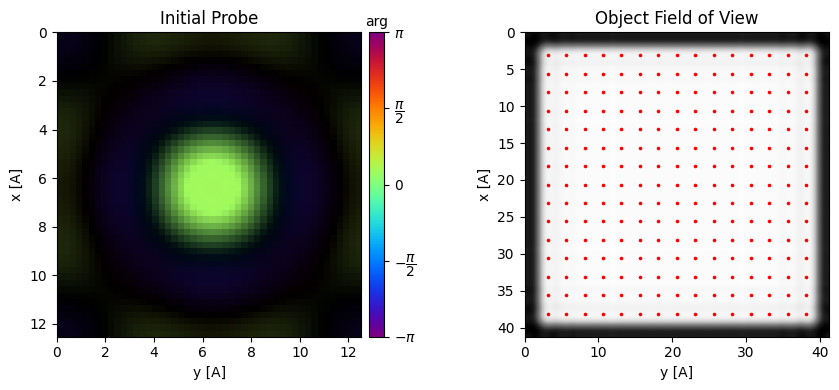

In [ ]:
ptycho_enough_overlap_small_alpha = dummy_dataset_preprocess(
    energy = 80e3, # V
    semiangle_cutoff = 10, #mrad
    defocus = 100, # ang
    scan_step_size_ang = 2.5,
    maximum_scattering_angle_mrad = 80,
    num_detector_pixels = 48,
)

2. Decreasing the scan step-size (which restricts the field of view)

Reconstruction pixel size: 0.261 A
Reconstruction object size: (54, 54) px


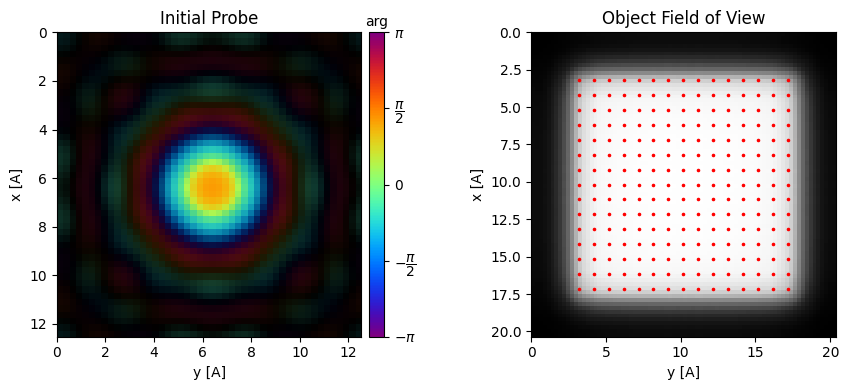

In [ ]:
ptycho_enough_overlap_small_fov = dummy_dataset_preprocess(
    energy = 80e3, # V
    semiangle_cutoff = 20, #mrad
    defocus = 100, # ang
    scan_step_size_ang = 1.0,
    maximum_scattering_angle_mrad = 80,
    num_detector_pixels = 48,
)

3. Increasing the defocus

Reconstruction pixel size: 0.261 A
Reconstruction object size: (136, 136) px


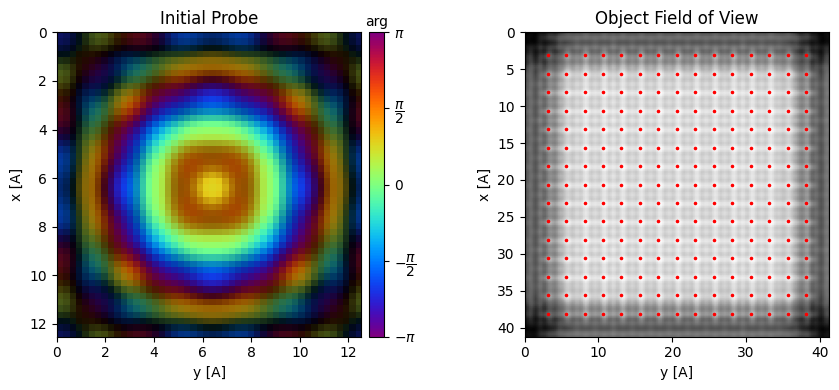

In [ ]:
ptycho_enough_overlap_probe_artifacts = dummy_dataset_preprocess(
    energy = 80e3, # V
    semiangle_cutoff = 20, #mrad
    defocus = 300, # ang
    scan_step_size_ang = 2.5,
    maximum_scattering_angle_mrad = 80,
    num_detector_pixels = 48,
)

Notice however how our probe no-longer fits in a (48,48) array - leading to wrap-around artifacts.  
This can be remedied using more detector pixels.

Reconstruction pixel size: 0.261 A
Reconstruction object size: (136, 136) px


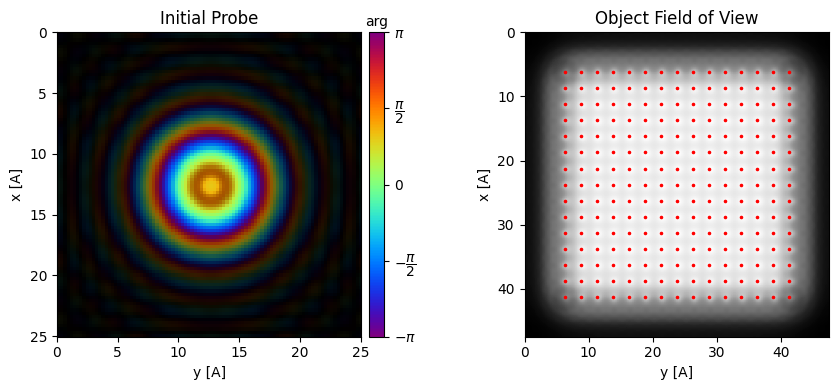

In [ ]:
ptycho_enough_overlap = dummy_dataset_preprocess(
    energy = 80e3, # V
    semiangle_cutoff = 20, #mrad
    defocus = 300, # ang
    scan_step_size_ang = 2.5,
    maximum_scattering_angle_mrad = 80,
    num_detector_pixels = 96,
)

The above might appear as a moot point, considering most detectors have a fixed number of pixels anyway. However, in ptychographic reconstructions we often want to bin the 4DSTEM data to increase our signal-to-noise ratio/dynamic range as-well as for computational efficiency.

Finally, let's see the effect of the maximum scattering angle on our setup:

Reconstruction pixel size: 0.522 A
Reconstruction object size: (69, 69) px


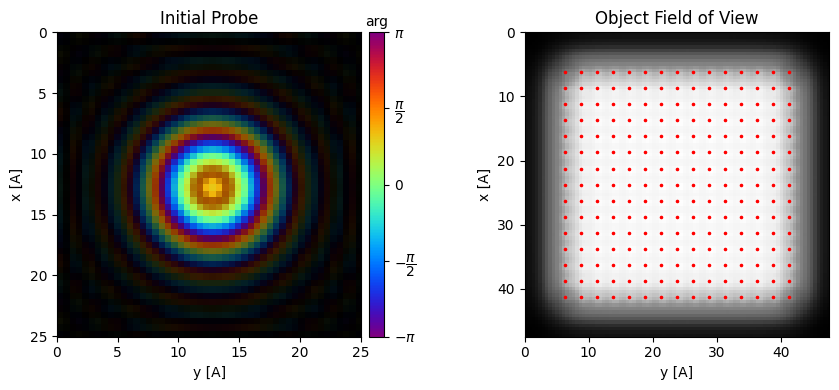

In [ ]:
ptycho_enough_overlap_lower_resolution = dummy_dataset_preprocess(
    energy = 80e3, # V
    semiangle_cutoff = 20, #mrad
    defocus = 300, # ang
    scan_step_size_ang = 2.5,
    maximum_scattering_angle_mrad = 40,
    num_detector_pixels = 48,
)

We can achieve the same setup as above, by using only (48,48) detector pixels and half the maximum scattering angle. However, notice that our reconstruction pixel size is now twice as large and thus our resolution will likely suffer.  

In general, you should only simulate/collect data up to scattering angles you have sufficient counts in. In detectors with a small dynamic range, this is often restricted to the bright field disk. In detectors with a large dynamic range, collecting to higher angles (so called "dark" electrons) enables super-resolution.

## 'Complex' Atomic Model Simulation

Let's use the atomic simulation environment (`ase`) and `abtem` to simulate a complicated non-periodic field of view, for use in ptychography.

we start by specifying the SrTiO$_3$ unit-cell:

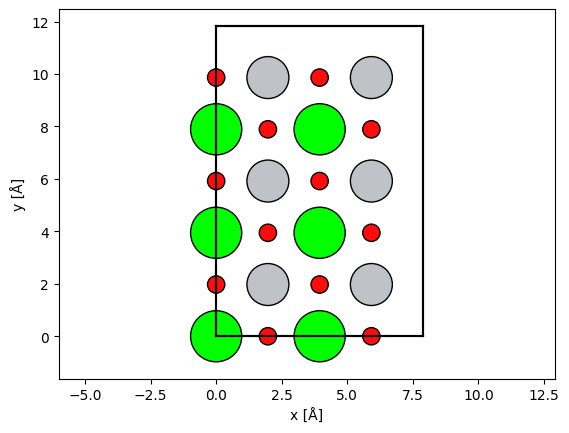

In [ ]:
STO_unit_cell = ase.Atoms(
    'SrTiO3',
    positions=[
        [0.      , 0.      , 0.      ],
        [1.972565, 1.972565, 1.972565],
        [0.      , 1.972565, 1.972565],
        [1.972565, 0.      , 1.972565],
        [1.972565, 1.972565, 0.      ]],
    cell=[3.94513, 3.94513, 3.94513]
)

abtem.show_atoms(STO_unit_cell * (2,3,1), plane='xy');

This is orientated along the [100] direction by default.
We will use `ase.build.surface` to create a [110] slab instead w/ 4 layers:

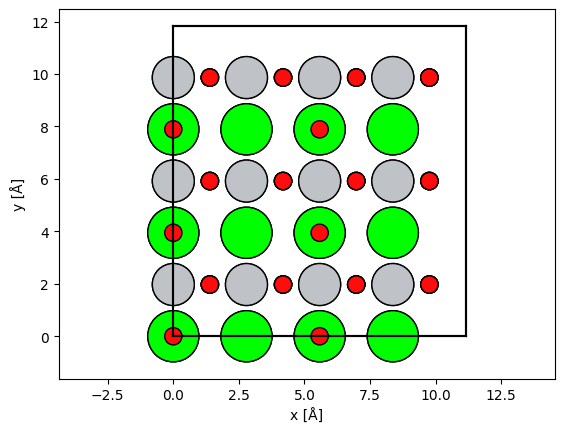

In [ ]:
STO_slab = ase.build.surface(STO_unit_cell, (1, 1, 0), 4, periodic=True) * (2,3,1)
abtem.show_atoms(STO_slab, plane='xy');

Let's rotate the structure by 20$^{\circ}$, and add some vacuum:

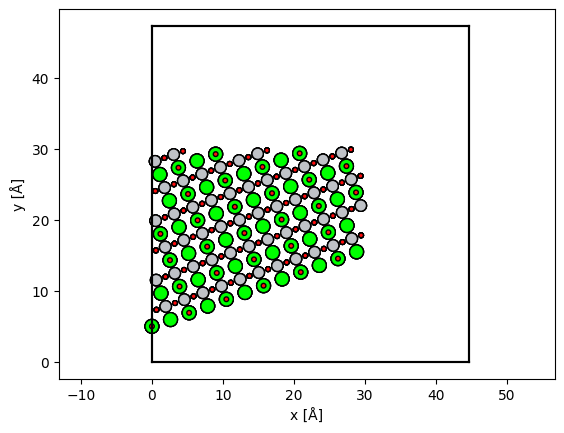

In [ ]:
STO_atoms = STO_slab * (4,4,2)
STO_atoms.rotate(20, 'z')
STO_atoms.positions[:,1] += 5
del STO_atoms[STO_atoms.positions[:,0]>30]
del STO_atoms[STO_atoms.positions[:,0]<0]
del STO_atoms[STO_atoms.positions[:,1]>30]
del STO_atoms[STO_atoms.positions[:,1]<0]
abtem.show_atoms(STO_atoms, plane='xy');

In [ ]:
STO_atoms.cell.array

array([[44.63405081,  0.        ,  0.        ],
       [ 0.        , 47.34156   ,  0.        ],
       [ 0.        ,  0.        , 22.31702541]])

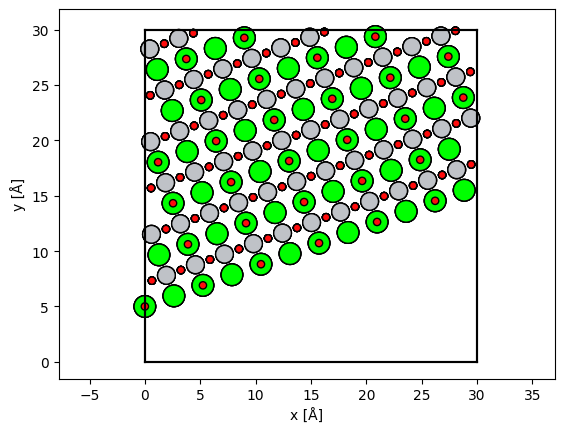

In [ ]:
STO_atoms = STO_slab * (4,4,2)
STO_atoms.rotate(20, 'z')
STO_atoms.positions[:,1] += 5
del STO_atoms[STO_atoms.positions[:,0]>30]
del STO_atoms[STO_atoms.positions[:,0]<0]
del STO_atoms[STO_atoms.positions[:,1]>30]
del STO_atoms[STO_atoms.positions[:,1]<0]
STO_atoms.cell[0,0] = 30
STO_atoms.cell[1,1] = 30

abtem.show_atoms(STO_atoms, plane='xy');

Note how we made the cell quite large, even though we don't plan on simulating the entire field-of-view, to avoid any periodic artifacts from the multislice simulation.
We define a grid-scan with a quarter of the field-of-view, i.e. 31x31 probe positions with a scan step-size of 0.5Å

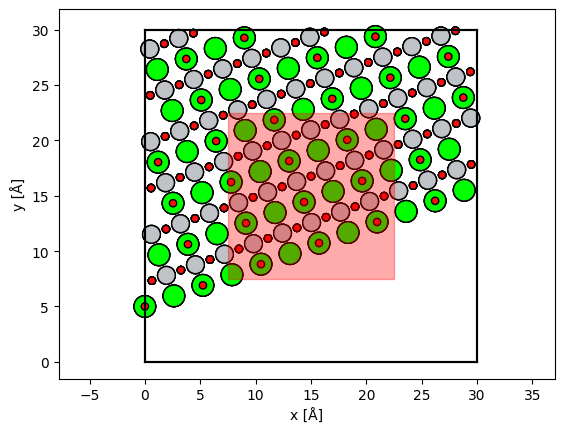

In [ ]:
scan_step_size = 0.5

gridscan = abtem.GridScan(
    (7.5,7.5),
    (22.5,22.5),
    sampling= scan_step_size,
    endpoint=True
)

abtem.show_atoms(STO_atoms,scans=gridscan);

We will define \# of detector pixels and our target real-space sampling. This will allows us to set the detector sampling and extent.

In [ ]:
num_detector_pixels = 80
target_sampling = 0.15
energy = 200e3
semiangle_cutoff = 20
defocus = 100

reciprocal_sampling = 1/target_sampling/num_detector_pixels
maximum_scattering_angle_mrad = reciprocal_sampling*num_detector_pixels/2*py4DSTEM.process.utils.electron_wavelength_angstrom(energy)*1000
resample=maximum_scattering_angle_mrad*2/num_detector_pixels

pixelated_detector = abtem.PixelatedDetector(max_angle=maximum_scattering_angle_mrad*0.99,resample=(resample,resample))

Before we run the simulation, we use our dummy preprocessing tool to check our simulation parameters looks good:
- [x] Our real-space probe fits comfortably in the cropping box
- [x] There's sufficient probe overlap

Reconstruction pixel size: 0.15 A
Reconstruction object size: (100, 100) px


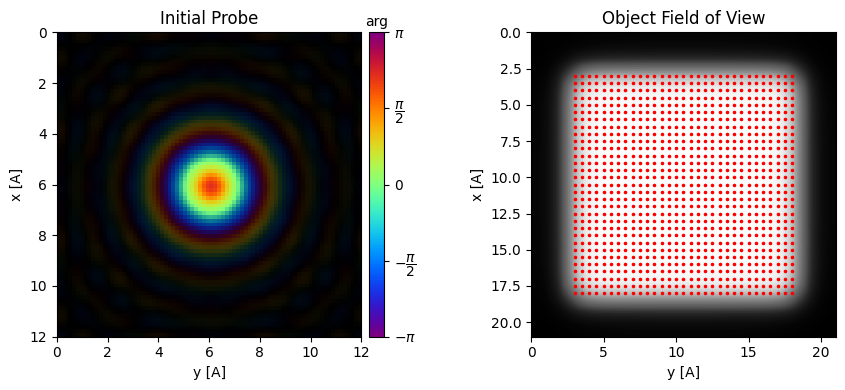

In [ ]:
pre_simulation_parameter_check = dummy_dataset_preprocess(
    energy = energy,
    semiangle_cutoff = semiangle_cutoff,
    defocus = defocus,
    scan_step_size_ang = scan_step_size,
    maximum_scattering_angle_mrad = maximum_scattering_angle_mrad,
    num_detector_pixels = num_detector_pixels,
    sx=31,sy=31
)

We then proceed to simulate our diffraction intensities (should take ~1 min):

In [ ]:
potential = abtem.Potential(
    STO_atoms,
    sampling=0.1,
    projection="infinite",
    parametrization="kirkland",
    device='gpu'
)

probe = abtem.Probe(energy=energy,semiangle_cutoff=semiangle_cutoff,defocus=defocus, device='gpu')

measurement = probe.scan(gridscan, pixelated_detector, potential)

Potential:   0%|          | 0/45 [00:00<?, ?it/s]

Scan:   0%|          | 0/961 [00:00<?, ?it/s]

Finally, we add some finite electron dose and compare the results against the infinite dose simulation:

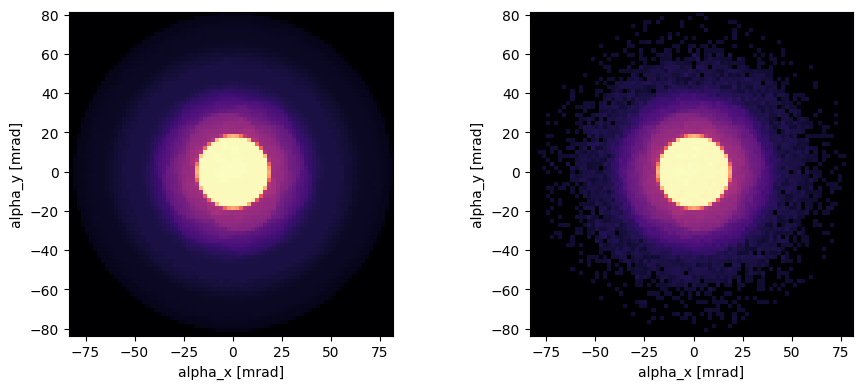

In [ ]:
from abtem.noise import poisson_noise

noisy_measurement = poisson_noise(measurement,1e5)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(9.5,4))
measurement.mean((0,1)).show(ax=ax1,power=0.25,cmap='magma')
noisy_measurement.mean((0,1)).show(ax=ax2,power=0.25,cmap='magma')
fig.tight_layout();

## py4STEM Ptychographic Reconstruction

Finally, we reconstruct the simulated dataset using single-slice ptychography:

In [ ]:
noisy_measurement.array.shape

(31, 31, 80, 80)

In [ ]:
dc = py4DSTEM.DataCube(data = noisy_measurement.array)
dc.calibration.set_R_pixel_size(noisy_measurement.calibrations[0].sampling)
dc.calibration.set_R_pixel_units('A')
dc.calibration.set_Q_pixel_size(noisy_measurement.calibrations[-1].sampling)
dc.calibration.set_Q_pixel_units('mrad')
dc.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:    2.089944779753115
             R_pixel_size:    0.5
             Q_pixel_units:   mrad
             R_pixel_units:   A
)

Reconstructing object and probe: 100%|██████████| 64/64 [00:08<00:00,  7.30 iter/s]


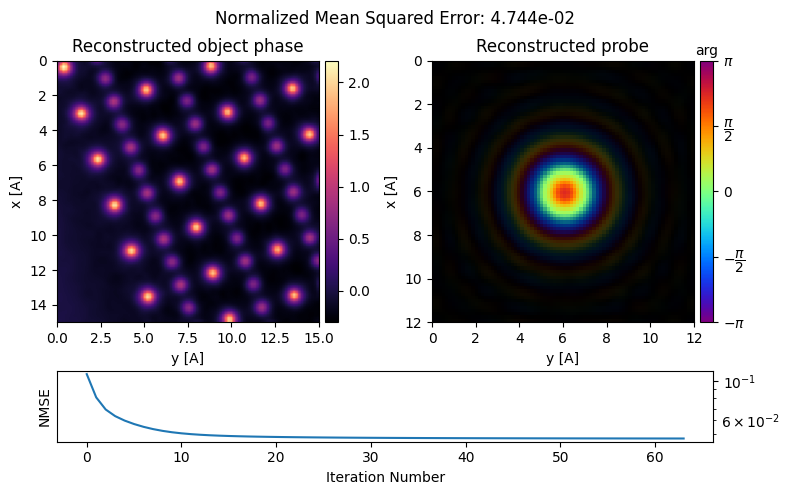

In [ ]:
ptycho = py4DSTEM.process.phase.SingleslicePtychographicReconstruction(
    datacube=dc,
    verbose=False,
    energy=200e3,
    semiangle_cutoff=20,
    defocus=100,
    object_padding_px=(12,12),
    device='gpu',
).preprocess(
    plot_center_of_mass = False,
    plot_rotation=False,
    plot_probe_overlaps=False,
    force_com_rotation=0,
    force_com_transpose=False,
).reconstruct(
    progress_bar = True,
    reset=True,
    store_iterations=True,
    reconstruction_method='GD',
    max_iter = 64,
    normalization_min=1,
    step_size=0.5,
).visualize(
    cbar=True,
)

Reconstructing object and probe: 100%|██████████| 12/12 [00:00<00:00, 30.40 iter/s]


SingleslicePtychographicReconstruction( A Node called 'ptychographic_reconstruction', containing the following top-level objects in its tree:

)

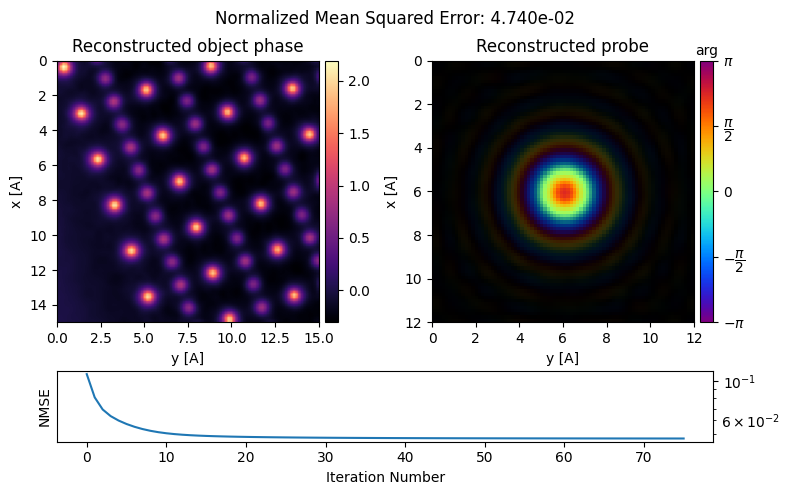

In [ ]:
ptycho.reconstruct(
    progress_bar = True,
    reset=False,
    store_iterations=True,
    reconstruction_method='GD',
    max_iter = 12,
    normalization_min=1,
    step_size=0.5,
).visualize(
    cbar=True,
)